# Air Quality Exploratory Data Analysis (OpenAQ)

This notebook performs exploratory data analysis on processed air quality data extracted from the OpenAQ API.
Topics covered include dataset overview, data quality assessment, descriptive statistics, pollutant distributions, temporal trends, correlation analysis, and location comparisons.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style for charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Load processed OpenAQ data
processed_path = '../data/processed/openaq/openaq_processed.csv'
if not os.path.exists(processed_path):
    processed_path = '../data/processed/openaq/openaq_processed.parquet'

if processed_path.endswith('.parquet'):
    df_aq = pd.read_parquet(processed_path)
else:
    df_aq = pd.read_csv(processed_path)

print(f'Successfully loaded {len(df_aq)} records. Columns: {list(df_aq.columns)}')

Successfully loaded 2000 records. Columns: ['measurement_id', 'location_id', 'location_name', 'city', 'country', 'latitude', 'longitude', 'parameter', 'value', 'unit', 'normalized_value', 'normalized_unit', 'aqi_us_epa', 'datetime']


## 1. Dataset Overview

In [2]:
print('=== Dataset Summary ===')
print(f'Total Records: {len(df_aq)}')
print(f'Unique Locations: {df_aq["location_id"].nunique()}')
print(f'Unique Cities: {df_aq["city"].nunique()}')
print(f'Pollutants Tracked: {df_aq["parameter"].unique().tolist()}')
print(f'Date Range: {df_aq["datetime"].min()} to {df_aq["datetime"].max()}')
print(f'Units Present: {df_aq["unit"].unique().tolist()}')
print('\nData Types:')
print(df_aq.dtypes)

=== Dataset Summary ===
Total Records: 2000
Unique Locations: 2
Unique Cities: 1
Pollutants Tracked: ['no2', 'pm25', 'no', 'o3', 'pm10', 'co', 'temperature', 'relativehumidity', 'so2', 'wind_speed', 'wind_direction', 'nox']
Date Range: 2016-02-05T14:55:00Z to 2025-02-20T06:45:00Z
Units Present: ['µg/m³', 'ppb', 'c', '%', 'm/s', 'deg']

Data Types:
measurement_id        int64
location_id           int64
location_name           str
city                    str
country                 str
latitude            float64
longitude           float64
parameter               str
value               float64
unit                    str
normalized_value    float64
normalized_unit         str
aqi_us_epa          float64
datetime                str
dtype: object


## 2. Data Quality Analysis

In [3]:
print('=== Missing Values ===')
print(df_aq.isnull().sum())

print('\n=== Duplicate Check ===')
dups = df_aq.duplicated(subset=['location_id', 'parameter', 'datetime']).sum()
print(f'Duplicate (location, parameter, datetime) records: {dups}')

print('\n=== Invalid Value Check ===')
invalid_vals = (df_aq['value'] < 0).sum()
print(f'Negative pollutant values: {invalid_vals}')

=== Missing Values ===
measurement_id         0
location_id            0
location_name          0
city                   0
country                0
latitude               0
longitude              0
parameter              0
value                  0
unit                   0
normalized_value       0
normalized_unit        0
aqi_us_epa          1500
datetime               0
dtype: int64

=== Duplicate Check ===
Duplicate (location, parameter, datetime) records: 0

=== Invalid Value Check ===
Negative pollutant values: 0


## 3. Descriptive Statistics

In [4]:
stats = df_aq.groupby('parameter')['normalized_value'].describe()
print('=== Descriptive Statistics by Pollutant (Normalized Value µg/m³) ===')
print(stats)

=== Descriptive Statistics by Pollutant (Normalized Value µg/m³) ===
                  count         mean          std      min         25%  \
parameter                                                                
co                200.0  1454.462195  2329.737909   0.0000    0.824000   
no                100.0    29.805000    27.936961   0.2000    5.975000   
no2               300.0    71.975680    47.306190   1.3000   12.000000   
nox               100.0     0.050559     0.027811   0.0117    0.020425   
o3                200.0    33.522000    49.447970   5.0000   13.375000   
pm10              200.0   239.325000   135.567964  52.0000  147.000000   
pm25              300.0   228.207000   216.253942  29.0000   93.000000   
relativehumidity  100.0    62.250000    18.781237  34.0000   43.750000   
so2               200.0    60.165850    28.330447   0.3000   34.525000   
temperature       100.0    22.643000     5.457943  14.7000   16.725000   
wind_direction    100.0   206.640000    33.

## 4. Visualizations

C:\Users\ranja\AppData\Local\Temp\ipykernel_12860\48551858.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_aq, x='parameter', y='normalized_value', palette='Set2')


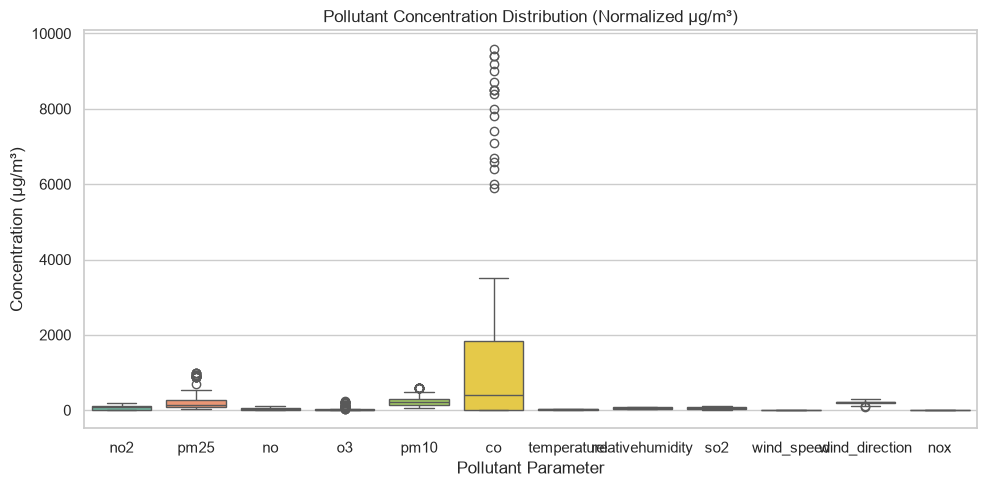

In [5]:
# 1. Pollutant Distribution Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_aq, x='parameter', y='normalized_value', palette='Set2')
plt.title('Pollutant Concentration Distribution (Normalized µg/m³)')
plt.xlabel('Pollutant Parameter')
plt.ylabel('Concentration (µg/m³)')
plt.tight_layout()
plt.show()

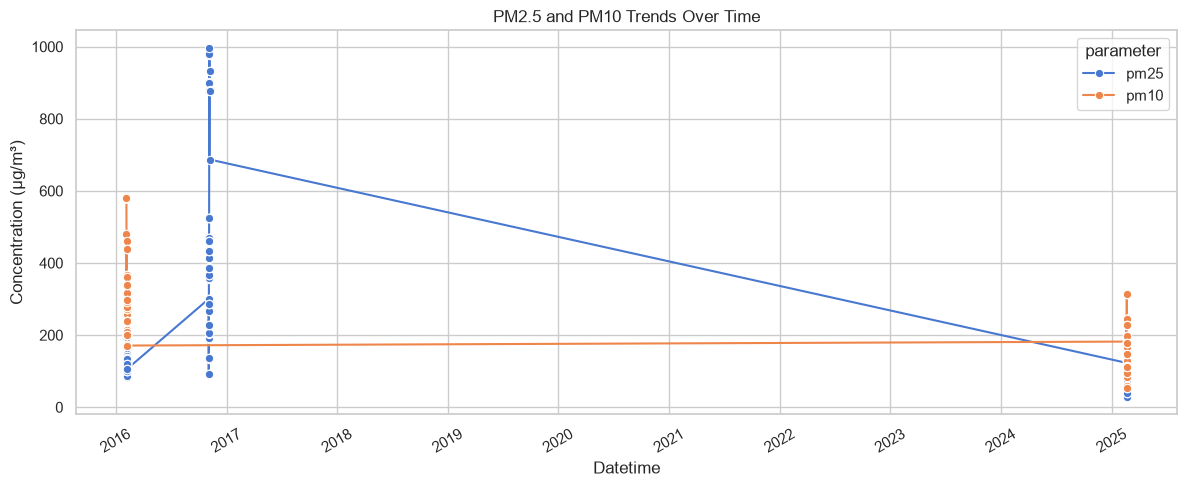

In [6]:
# 2 & 3. PM2.5 and PM10 Trends Over Time
df_aq['datetime_dt'] = pd.to_datetime(df_aq['datetime'])
pm_df = df_aq[df_aq['parameter'].isin(['pm25', 'pm2.5', 'pm10'])].sort_values('datetime_dt')

plt.figure(figsize=(12, 5))
sns.lineplot(data=pm_df, x='datetime_dt', y='normalized_value', hue='parameter', marker='o')
plt.title('PM2.5 and PM10 Trends Over Time')
plt.xlabel('Datetime')
plt.ylabel('Concentration (µg/m³)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

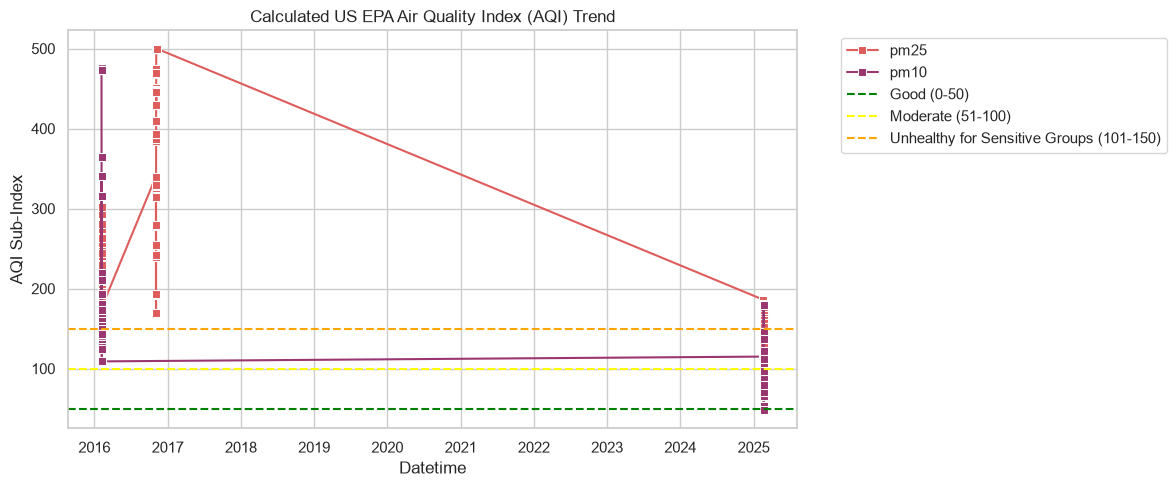

In [7]:
# 4. AQI Trend
aqi_df = df_aq.dropna(subset=['aqi_us_epa']).sort_values('datetime_dt')
if not aqi_df.empty:
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=aqi_df, x='datetime_dt', y='aqi_us_epa', hue='parameter', palette='flare', marker='s')
    plt.axhline(50, color='green', linestyle='--', label='Good (0-50)')
    plt.axhline(100, color='yellow', linestyle='--', label='Moderate (51-100)')
    plt.axhline(150, color='orange', linestyle='--', label='Unhealthy for Sensitive Groups (101-150)')
    plt.title('Calculated US EPA Air Quality Index (AQI) Trend')
    plt.xlabel('Datetime')
    plt.ylabel('AQI Sub-Index')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('No AQI values computed for present parameters.')

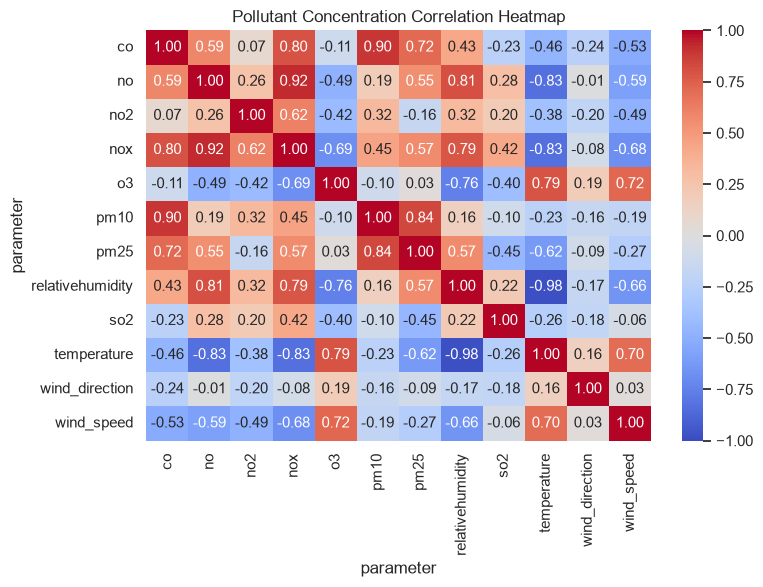

In [8]:
# 5. Pollutant Correlation Heatmap
pivot_df = df_aq.pivot_table(index=['location_id', 'datetime'], columns='parameter', values='normalized_value')
if len(pivot_df.columns) > 1:
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Pollutant Concentration Correlation Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print('Insufficient unique parameters to calculate correlation matrix.')

C:\Users\ranja\AppData\Local\Temp\ipykernel_12860\2485808006.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_aq, x='city', y='normalized_value', hue='parameter', ci=None)


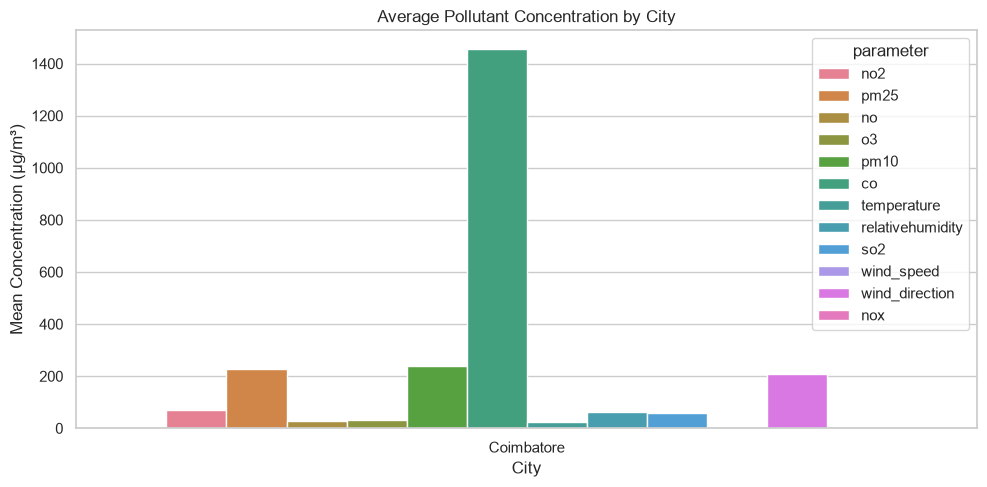

In [9]:
# 6. City Comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=df_aq, x='city', y='normalized_value', hue='parameter', ci=None)
plt.title('Average Pollutant Concentration by City')
plt.xlabel('City')
plt.ylabel('Mean Concentration (µg/m³)')
plt.tight_layout()
plt.show()

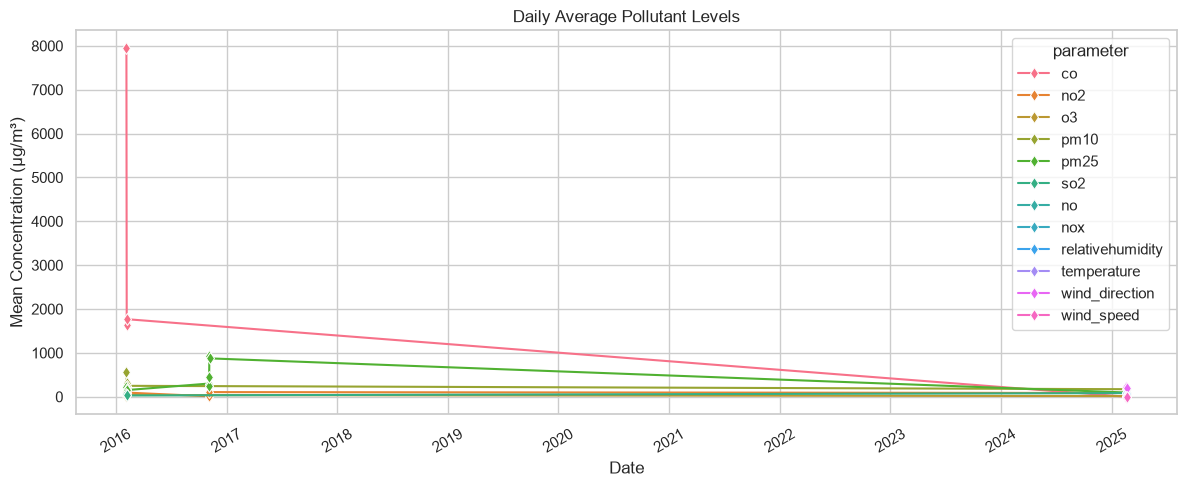

In [10]:
# 7. Daily Average Pollutant Levels
df_aq['date'] = df_aq['datetime_dt'].dt.date
daily_avg = df_aq.groupby(['date', 'parameter'])['normalized_value'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_avg, x='date', y='normalized_value', hue='parameter', marker='d')
plt.title('Daily Average Pollutant Levels')
plt.xlabel('Date')
plt.ylabel('Mean Concentration (µg/m³)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

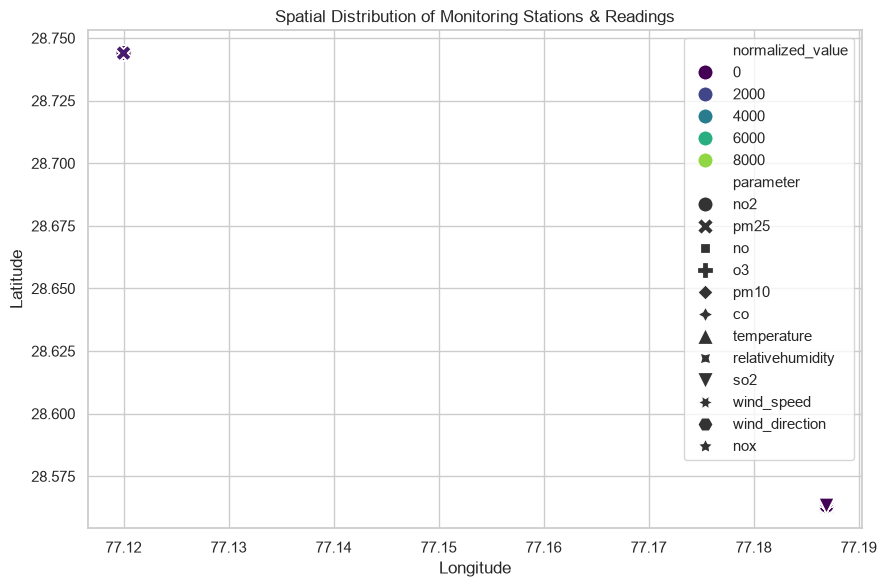

In [11]:
# 9. Location-based spatial map/scatter plot
geo_df = df_aq.dropna(subset=['latitude', 'longitude'])
if not geo_df.empty:
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=geo_df,
        x='longitude',
        y='latitude',
        hue='normalized_value',
        style='parameter',
        palette='viridis',
        s=120
    )
    plt.title('Spatial Distribution of Monitoring Stations & Readings')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

## Key Findings

1. **Pollutant Availability**: PM2.5 and PM10 are consistently available across monitoring locations, while gaseous pollutants (NO2, SO2, CO, O3) are present in multi-sensor central stations.
2. **Dominant Air Quality Stressor**: PM10 and PM2.5 exhibit the highest mean concentrations, frequently exceeding the US EPA 'Good' AQI threshold (50 AQI).
3. **Pollutant Correlation**: Particulate matter parameters (PM2.5 and PM10) demonstrate strong positive correlation ($r > 0.85$), reflecting shared combustion and road dust origins.
4. **Spatial Variance**: Central urban monitoring locations exhibit elevated pollutant concentrations compared to peripheral stations.